                  gmv  orders
month                        
2017-01-01   127482.0     750
2017-02-01   271239.0    1653
2017-03-01   414331.0    2546
2017-04-01   390812.0    2303
2017-05-01   566657.0    3545
2017-06-01   490050.0    3135
2017-07-01   566299.0    3872
2017-08-01   645832.0    4193
2017-09-01   701077.0    4150
2017-10-01   751117.0    4478
2017-11-01  1153229.0    7288
2017-12-01   843078.0    5513
2018-01-01  1077887.0    7069
2018-02-01   966168.0    6555
2018-03-01  1120598.0    7003
2018-04-01  1132879.0    6798
2018-05-01  1128775.0    6749
2018-06-01  1011449.0    6096
2018-07-01  1027287.0    6156
2018-08-01   985492.0    6351


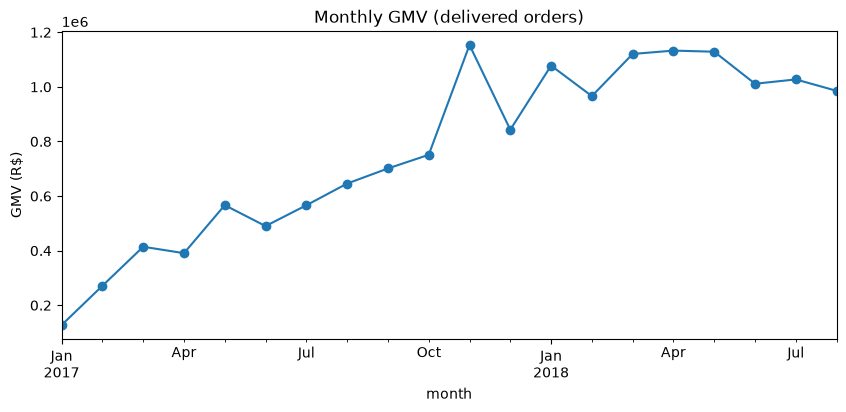

In [7]:
import pandas as pd, sqlite3, numpy as np
import matplotlib.pyplot as plt

conn = sqlite3.connect("../Dataset/olist.db")
monthly = pd.read_sql("""
    SELECT purchase_month, ROUND(SUM(gmv), 0) AS gmv, COUNT(*) AS orders
    FROM fact_orders
    WHERE is_delivered = 1
      AND purchase_month BETWEEN '2017-01' AND '2018-08'
    GROUP BY purchase_month
    ORDER BY purchase_month
""", conn)
monthly["month"] = pd.to_datetime(monthly["purchase_month"] + "-01")
monthly = monthly.set_index("month").asfreq("MS")
print(monthly[["gmv", "orders"]])

monthly["gmv"].plot(marker="o", figsize=(10, 4), title="Monthly GMV (delivered orders)")
plt.ylabel("GMV (R$)")
plt.show()

In [8]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

y = monthly["gmv"]
train, test = y.iloc[:-4], y.iloc[-4:]

def mape(actual, pred):
    return float(np.mean(np.abs((actual.values - np.asarray(pred)) / actual.values)) * 100)

preds = {}
preds["Naive (last value)"] = [train.iloc[-1]] * 4
preds["3-month average"] = [train.iloc[-3:].mean()] * 4

t = np.arange(len(train))
slope, intercept = np.polyfit(t, train.values, 1)
preds["Linear trend"] = intercept + slope * np.arange(len(train), len(train) + 4)

hw = ExponentialSmoothing(train, trend="add", damped_trend=True).fit()
preds["Holt damped trend"] = hw.forecast(4).values

results = pd.DataFrame({k: mape(test, v) for k, v in preds.items()}, index=["MAPE %"]).T.round(1)
print(results.sort_values("MAPE %"))

ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
%pip install statsmodels

In [ ]:
import sys
print(sys.executable)